# Image classification using HOG and SVM

## Fine tuning Support Vector Machines for Better Accuracy

In [1]:
# Imports
import os
import numpy as np
import matplotlib.pyplot as plt
from skimage.io import imread
from skimage.transform import resize
from skimage.feature import hog
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import seaborn as sns

## Objective
To classify images into their respective categories using:
- HOG (Histogram of Oriented Gradients) for feature extraction
- SVM (SUpport Vector Machine) for classification

We also evaluate the effect of hyperparameter tuning on model performance


## Data preparation
- Images are resized to '128x128'
- Converted to grayscale
- HOG features are extracted for classification
- Dataset includes training and test sets organized in folders per class

In [2]:
# Directory paths
DATA_DIR = "./dataset_2"
TEST_DIR = "./test"

# Image processing
IMG_SIZE = (128, 128)

# HOG parameters
ORIENTATIONS = 9
PIXELS_PER_CELL = (8, 8)
CELLS_PER_BLOCK = (2, 2)


## HOG feature Extraction Function

### With data preprocessing
HOG captures edge information and is effective for object recognition.
- 'orientations = 9', 'pixels_per_cell=(8,8), 'cells_per_block=(2,2)'


In [3]:
def extract_hog_features(data_dir):
    features = []
    labels = []
    class_names = sorted(os.listdir(data_dir))

    for label_idx, class_name in enumerate(class_names):
        class_path = os.path.join(data_dir, class_name)
        for img_name in os.listdir(class_path):
            img_path = os.path.join(class_path, img_name)
            try:
                img = imread(img_path)
                img = resize(img, IMG_SIZE, anti_aliasing=True)
                gray = np.mean(img, axis=2) if img.ndim == 3 else img  # Convert to grayscale
                hog_feat = hog(gray, 
                               orientations=ORIENTATIONS, 
                               pixels_per_cell=PIXELS_PER_CELL, 
                               cells_per_block=CELLS_PER_BLOCK,
                               block_norm='L2-Hys')
                features.append(hog_feat)
                labels.append(label_idx)
            except Exception as e:
                print(f"⚠️ Error loading {img_path}: {e}")

    return np.array(features), np.array(labels), class_names


Display the shape of extracted features

In [4]:
X_train, y_train, class_names = extract_hog_features(DATA_DIR)
X_test, y_test, _ = extract_hog_features(TEST_DIR)

print("✅ Feature extraction complete.")
print("Train set shape:", X_train.shape)
print("Test set shape:", X_test.shape)


✅ Feature extraction complete.
Train set shape: (480, 8100)
Test set shape: (480, 8100)


In [5]:
# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


## Baseline SVM Model
- Kernel: 'linear'
- C = 1.0
- StandardScaler is used for feature scaling

Display:
- Classification report
- Confusion Matrix
- Accuracy

Initial Test Classification Report (Before Tuning):
              precision    recall  f1-score   support

      glioma       0.97      0.93      0.95       120
  meningioma       0.87      0.82      0.85       120
     notumor       0.91      0.92      0.91       120
   pituitary       0.88      0.94      0.91       120

    accuracy                           0.90       480
   macro avg       0.90      0.90      0.90       480
weighted avg       0.90      0.90      0.90       480



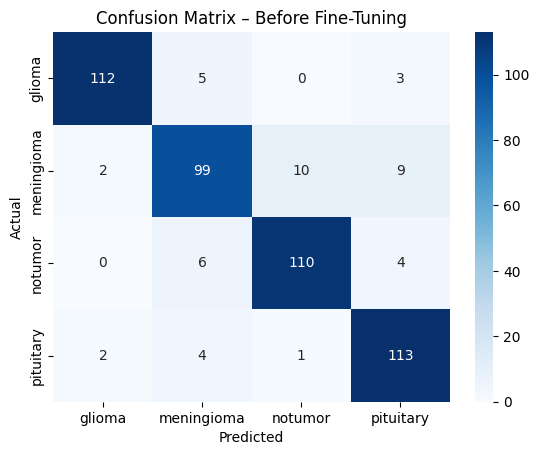

In [6]:
# Train SVM (Before fine-tuning)
clf_initial = SVC(kernel='linear', C=1.0)
clf_initial.fit(X_train_scaled, y_train)

y_pred_test_initial = clf_initial.predict(X_test_scaled)

print("Initial Test Classification Report (Before Tuning):")
print(classification_report(y_test, y_pred_test_initial, target_names=class_names))

conf_matrix = confusion_matrix(y_test, y_pred_test_initial)
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.title("Confusion Matrix – Before Fine-Tuning")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## Model Tuning with Grid Search
- We test different values for 'C', 'kernel', 'gamma'
- 5-fold cross validation

Displays the best parameters and results after tuning

In [7]:
param_grid = {
    'C': [0.1, 1, 10, 100],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 'auto']
}

grid = GridSearchCV(SVC(), param_grid, cv=5, n_jobs=-1, verbose=1)
grid.fit(X_train_scaled, y_train)

print(f"✅ Best Parameters: {grid.best_params_}")


Fitting 5 folds for each of 16 candidates, totalling 80 fits
✅ Best Parameters: {'C': 0.1, 'gamma': 'scale', 'kernel': 'linear'}


📋 Test Classification Report (After Tuning):
              precision    recall  f1-score   support

      glioma       0.97      0.93      0.95       120
  meningioma       0.87      0.82      0.85       120
     notumor       0.91      0.92      0.91       120
   pituitary       0.88      0.94      0.91       120

    accuracy                           0.90       480
   macro avg       0.90      0.90      0.90       480
weighted avg       0.90      0.90      0.90       480



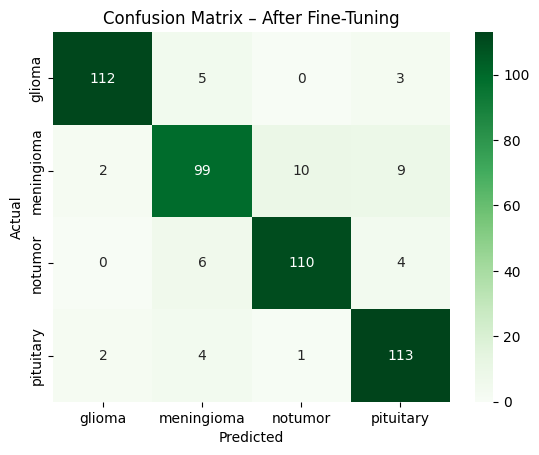

In [8]:
best_model = grid.best_estimator_
y_pred_test_tuned = best_model.predict(X_test_scaled)

print("📋 Test Classification Report (After Tuning):")
print(classification_report(y_test, y_pred_test_tuned, target_names=class_names))

conf_matrix = confusion_matrix(y_test, y_pred_test_tuned)
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Greens",
            xticklabels=class_names, yticklabels=class_names)
plt.title("Confusion Matrix – After Fine-Tuning")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


# Testing of model


In [9]:
import joblib

joblib.dump(best_model, 'best_svm_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

print("✅ Model and scaler saved successfully.")

✅ Model and scaler saved successfully.


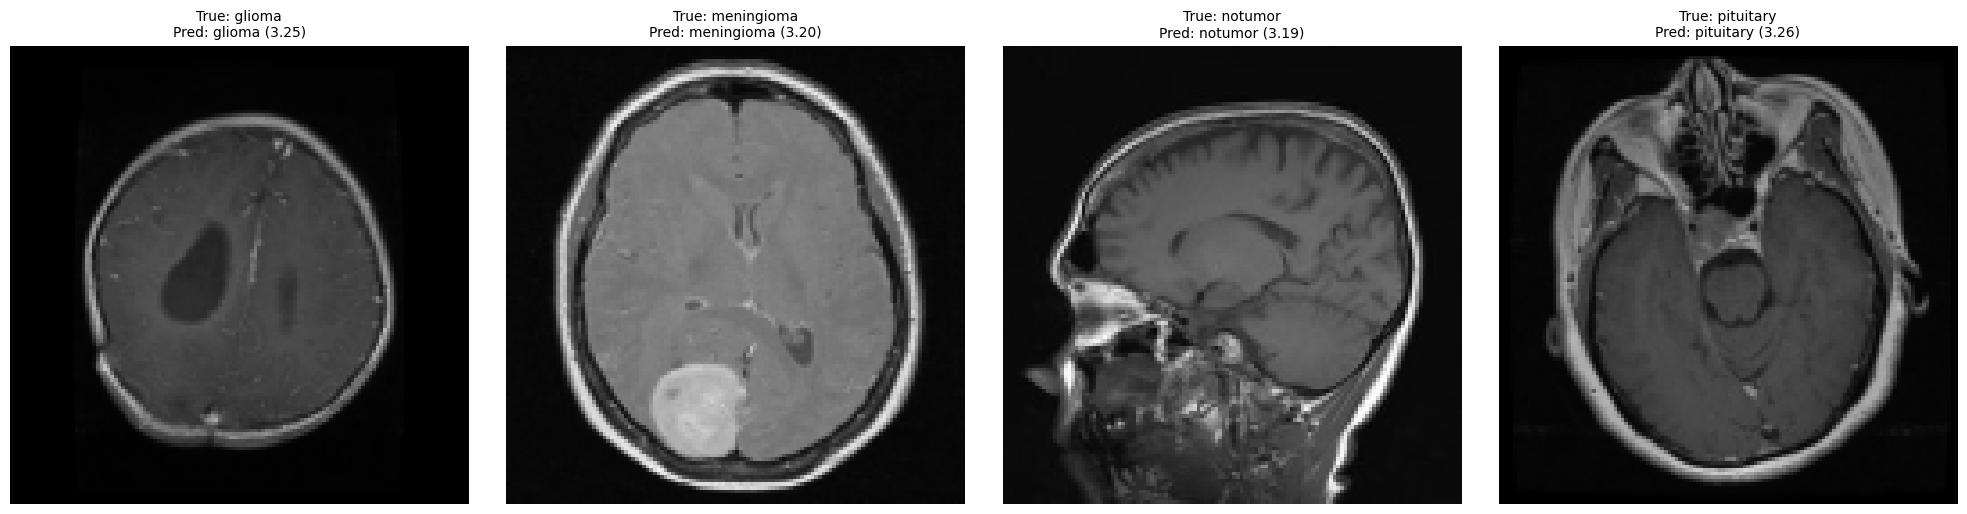

[1] Image: Te-gl_0018.jpg
     True Label:      glioma
     Predicted Label: glioma
     Confidence:      3.25
--------------------------------------------------
[2] Image: Te-me_0010.jpg
     True Label:      meningioma
     Predicted Label: meningioma
     Confidence:      3.20
--------------------------------------------------
[3] Image: Te-no_0015.jpg
     True Label:      notumor
     Predicted Label: notumor
     Confidence:      3.19
--------------------------------------------------
[4] Image: Te-pi_0014.jpg
     True Label:      pituitary
     Predicted Label: pituitary
     Confidence:      3.26
--------------------------------------------------


In [17]:
import os
import numpy as np
import matplotlib.pyplot as plt
from skimage.feature import hog
from skimage.transform import resize
from skimage.io import imread
import joblib
from sklearn.metrics import accuracy_score

# --- Settings ---
TEST_DIR = "./test"
IMG_SIZE = (128, 128)
class_names = ['glioma', 'meningioma', 'notumor', 'pituitary']

ORIENTATIONS = 9
PIXELS_PER_CELL = (8, 8)
CELLS_PER_BLOCK = (2, 2)

model = joblib.load('best_svm_model.pkl')
scaler = joblib.load('scaler.pkl')

images = []
hog_features = []
true_labels = []
file_names = []

# Load 1 image per class
N_per_class = 1

for class_name in class_names:
    count = 0  # reset count per class
    class_path = os.path.join(TEST_DIR, class_name)
    for img_name in os.listdir(class_path):
        if count >= N_per_class:
            break
        img_path = os.path.join(class_path, img_name)
        img = imread(img_path)
        img_resized = resize(img, IMG_SIZE, anti_aliasing=True)
        gray = np.mean(img_resized, axis=2) if img_resized.ndim == 3 else img_resized
        feat = hog(gray,
                   orientations=ORIENTATIONS,
                   pixels_per_cell=PIXELS_PER_CELL,
                   cells_per_block=CELLS_PER_BLOCK,
                   block_norm='L2-Hys')
        images.append(img_resized)
        hog_features.append(feat)
        true_labels.append(class_name)
        file_names.append(img_name)
        count += 1

hog_features = scaler.transform(hog_features)
probs = model.decision_function(hog_features)

predicted_indices = np.argmax(probs, axis=1)
confidences = np.max(probs, axis=1)
predicted_labels = [class_names[i] for i in predicted_indices]

total_images = N_per_class * len(class_names)

fig, axes = plt.subplots(1, total_images, figsize=(5 * total_images, 5))
for i in range(total_images):
    axes[i].imshow(images[i])
    axes[i].set_title(
        f"True: {true_labels[i]}\nPred: {predicted_labels[i]} ({confidences[i]:.2f})",
        fontsize=10
    )
    axes[i].axis('off')
plt.tight_layout()
plt.show()

for i in range(total_images):
    print(f"[{i+1}] Image: {file_names[i]}")
    print(f"     True Label:      {true_labels[i]}")
    print(f"     Predicted Label: {predicted_labels[i]}")
    print(f"     Confidence:      {confidences[i]:.2f}")
    print("-" * 50)


## Conclusion
- HOG + SVM provides solid performance for image classification 
- The baseline linear SVM already performed well at 90.42% accuracy. This indicates that the features extracted using HOG are highly separable with a linear decision boundary
- Despite tuning multiple parameters, the final accuracy remained unchanged. This suggest that the linear kernel with default settings is already optimal for this feature space.

With this performance, it suggests that the model is already well-suited to this task as after tuning, no significant gain was observed and still achieved an accuracy of 90.42%.

In [18]:
from sklearn.metrics import accuracy_score

initial_acc = accuracy_score(y_test, y_pred_test_initial)
tuned_acc = accuracy_score(y_test, y_pred_test_tuned)

print(f"Initial Accuracy: {initial_acc:.4f}")
print(f"Tuned Accuracy: {tuned_acc:.4f}")


Initial Accuracy: 0.9042
Tuned Accuracy: 0.9042
